In [13]:
import sys, os
sys.path.append('..')
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
temp_reso = 10
B, T, D = 4000, 300, 100

## Create sensory input

In [10]:
# Plot the normal distribution which is used to sample the temporal events
x = np.linspace(0, 8, 100)
signal_amp_mu, signal_amp_sigma = 4.0, 0.5
y = np.exp(-(x - signal_amp_mu)**2 / (2 * signal_amp_sigma**2))

In [11]:
# Sample 100 points from the normal distribution
rng1 = np.random.default_rng(seed=42)  # For reproducibility
rng2 = np.random.default_rng(seed=43)  # For reproducibility
temp_event_1 = rng1.normal(loc=signal_amp_mu, scale=signal_amp_sigma, size=(D,))
temp_event_2 = rng2.normal(loc=signal_amp_mu, scale=signal_amp_sigma, size=(D,))

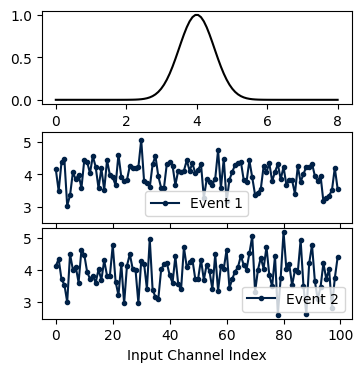

In [12]:
fig = plt.figure(figsize=(4, 4))

# Outer grid: controls gap between ax[0] and the lower block
outer = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.2)

ax0 = fig.add_subplot(outer[0, 0])

# Inner grid: controls ONLY gap between ax[1] and ax[2]
inner = outer[1, 0].subgridspec(2, 1, hspace=0.05)
ax1 = fig.add_subplot(inner[0, 0])
ax2 = fig.add_subplot(inner[1, 0], sharex=ax1, sharey=ax1)

# your plotting
ax0.plot(x, y, 'k')
ax1.plot(np.arange(len(temp_event_1)), temp_event_1, '.-', label='Event 1', color='#002147')
ax2.plot(np.arange(len(temp_event_2)), temp_event_2, '.-', label='Event 2', color='#002147')

ax1.tick_params(axis='x', labelbottom=False)
ax2.set_xlabel('Input Channel Index')
ax1.legend(loc='best')
ax2.legend(loc='best')

In [13]:
# === Method 2 === #
# Generate the first temporal event with shape n_channels, Select fixed random number from a normal distribution
event_dur = 2
onset_trial    = np.random.uniform(2.0*temp_reso, 13.0*temp_reso, (B, 1))           # one start per trial
event_1_onsets = (onset_trial + np.random.normal(0, 0.2*temp_reso, (B, D))).astype(int)  # optional ±0.2 s jitter
event_1_ends   = event_1_onsets + int(event_dur*temp_reso)
event_2_onsets = event_1_onsets + int(15.0*temp_reso)
event_2_ends   = event_2_onsets + int(event_dur*temp_reso)


# === Method 1 === #
# event_1_onset, event_1_end = 2.5, 3.0
# event_2_onset, event_2_end = 17.5, 18.0
# # Make the onset and end time randomly and convert to indices (sigma=0.2s)
# event_1_onsets = np.random.normal(event_1_onset*temp_reso, 0.2*temp_reso, (B, D)).astype(int)
# event_1_ends   = np.random.normal(event_1_end*temp_reso,   0.2*temp_reso, (B, D)).astype(int)
# event_2_onsets = np.random.normal(event_2_onset*temp_reso, 0.2*temp_reso, (B, D)).astype(int)
# event_2_ends   = np.random.normal(event_2_end*temp_reso,   0.2*temp_reso, (B, D)).astype(int)


sensory_profile = {
                    "time": {
                            "sigma":  0.5,    # sigma of Gaussian noise
                            "ssigma": 0.2,    # smoothing sigma of Gaussian noise (in sec)
                            "bias":   signal_amp_mu, 
                            },
                    }

In [14]:
# Generate random Gaussian noise
noisy_res = np.random.normal(sensory_profile['time']['bias'], sensory_profile['time']['sigma'], (B, T, D)) 
# Replace the noisy_res values with the temporal events at the specified onsets and ends
for b in range(B):
    for d in range(D):
        noisy_res[b, event_1_onsets[b, d]:event_1_ends[b, d], d] = temp_event_1[d]
        noisy_res[b, event_2_onsets[b, d]:event_2_ends[b, d], d] = temp_event_2[d]
# Smooth out the temporal profile
from scipy.ndimage import gaussian_filter
time_res = gaussian_filter(noisy_res, sigma=(0, sensory_profile['time']['ssigma'], 0)) 
print(time_res.shape)  # Should be (B, T, D)

(4000, 300, 100)


In [15]:
# Mask the inputs
from rtgym.utils.masking import Masking
# This mask ratio is the same as place cells in square room, not other time cells simulation.
mask = Masking(
                m_max=0.4,    # Maximum masking ratio
                m_min=0.2,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )

In [16]:
labels = time_res.copy()
inputs = mask.mask(time_res).numpy()

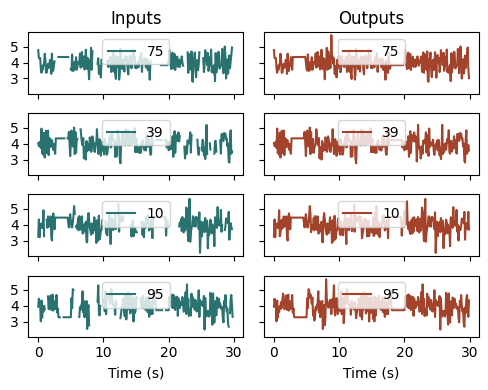

In [17]:
fig, ax = plt.subplots(4, 2, figsize=(5, 4), sharex=True, sharey=True)
rand_D = np.random.choice(D, size=4, replace=False)
b = 5
for i, channel in enumerate(rand_D):
    ax[i][0].plot(np.arange(inputs.shape[1]) / temp_reso , 
                  np.where(inputs[b, :, channel] == 0, np.nan, inputs[b, :, channel]),
                  label=f'{channel}', color='#297270')
    ax[i][0].legend(loc='upper center')

    ax[i][1].plot(np.arange(time_res.shape[1]) / temp_reso , 
                  time_res[b, :, channel], 
                  label=f'{channel}', color='#A3432B')
    ax[i][1].legend(loc='upper center')
    
ax[0][0].set_title('Inputs')
ax[0][1].set_title('Outputs')
ax[-1][0].set_xlabel('Time (s)')
ax[-1][1].set_xlabel('Time (s)')
plt.tight_layout()

In [18]:
# Split the data to training and test set along axis=1
from torch.utils.data import DataLoader, TensorDataset
import torch
import nn4n.nn

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


indices = np.arange(inputs.shape[0])
train_inputs, test_inputs, train_labels, test_labels, train_indices, \
test_indices = train_test_split(inputs, labels, indices, test_size=0.05, random_state=42)

if isinstance(train_inputs, np.ndarray):
    train_inputs  = torch.from_numpy(train_inputs).float().to(device)
    train_labels  = torch.from_numpy(train_labels).float().to(device)
    test_inputs   = torch.from_numpy(test_inputs).float().to(device)
    test_labels   = torch.from_numpy(test_labels).float().to(device)

print('train_inputs:',  train_inputs.shape)
print('train_labels:',  train_labels.shape)
print('test_inputs:',   test_inputs.shape)
print('test_labels:',   test_labels.shape)
print('train_indices:', train_indices.shape)
print('test_indices:',  test_indices.shape)

train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

Using device: cuda
train_inputs: torch.Size([3800, 300, 100])
train_labels: torch.Size([3800, 300, 100])
test_inputs: torch.Size([200, 300, 100])
test_labels: torch.Size([200, 300, 100])
train_indices: (3800,)
test_indices: (200,)


In [19]:
save_dict = {
            'train_inputs': train_inputs,
            'train_labels': train_labels,
            'test_inputs':  test_inputs,
            'test_labels':  test_labels,
        }
os.makedirs('../../data', exist_ok=True)
np.save('../../data/2TS_symmetry_M2.npy', save_dict)
print('Saved!')

Saved!


In [3]:
# Reload tensors saved on CUDA, move them to CPU, and resave as NumPy arrays
import io
import torch

source_path = '../../data/2TS_symmetry_M2.npy'
target_path = '../../data/2TS_symmetry_M2_numpy.npy'

original_load_from_bytes = torch.storage._load_from_bytes

def load_from_bytes_on_cpu(buffer):
    return torch.load(io.BytesIO(buffer), map_location='cpu', weights_only=False)

try:
    torch.storage._load_from_bytes = load_from_bytes_on_cpu
    data = np.load(source_path, allow_pickle=True).item()
finally:
    torch.storage._load_from_bytes = original_load_from_bytes

numpy_data = {
    key: value.detach().cpu().numpy() if isinstance(value, torch.Tensor) else np.asarray(value)
    for key, value in data.items()
}
np.save(target_path, numpy_data, allow_pickle=True)
print(f'Saved NumPy data to {target_path}')
print({key: value.shape for key, value in numpy_data.items()})

Saved NumPy data to ../../data/2TS_symmetry_M2_numpy.npy
{'train_inputs': (3800, 300, 100), 'train_labels': (3800, 300, 100), 'test_inputs': (200, 300, 100), 'test_labels': (200, 300, 100), 'test_outputs': (200, 300, 100), 'test_hidden_states': (200, 300, 512), 'train_losses': (30000,)}


## Visualize the training result

In [14]:
data = np.load('../../data/2TS_symmetry_M2_numpy.npy', allow_pickle=True).item()
losses = data['train_losses']
test_outputs = data['test_outputs']
test_inputs = data['test_inputs']
test_labels = data['test_labels']
hidden_states = data['test_hidden_states']

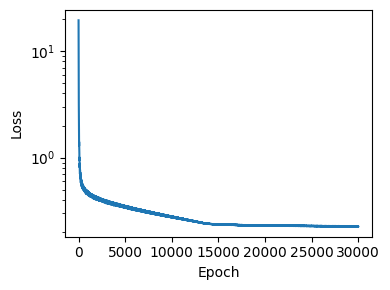

In [15]:
plt.figure(figsize=(4, 3))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

Text(0.5, 0, 'Time (s)')

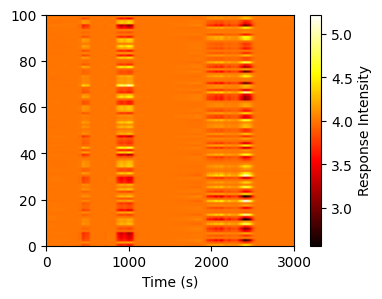

In [16]:
# Plot the outputs
plt.figure(figsize=(4, 3))
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso, 0, D])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')

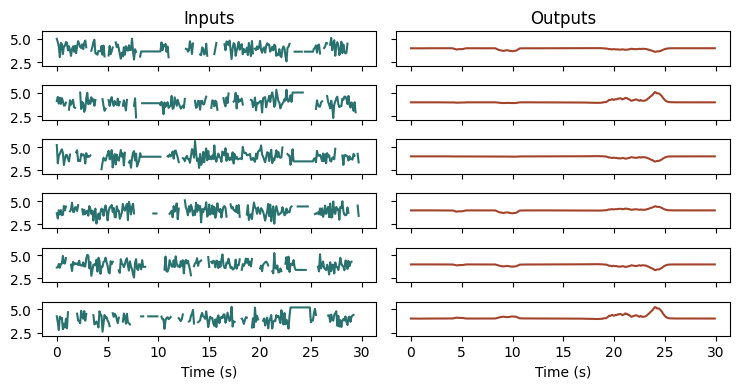

In [17]:
fig, ax = plt.subplots(6, 2, figsize=(5 * T/200, 4), sharex=True, sharey=True)
# Randomly sample a few channels to plots
rand_D = np.random.choice(D, size=6, replace=False)
for i, channel in enumerate(rand_D):
    
    ax[i][0].plot(np.arange(test_inputs.shape[1]) / 10, 
                # Replace the test_inputs 0 with nan
                np.where(test_inputs[0, :, channel] == 0, np.nan, test_inputs[0, :, channel]),
                label=f'{channel}', color='#297270')

    ax[i][-1].plot(np.arange(test_outputs.shape[1]) / 10, 
                  test_outputs[0, :, channel], 
                  label=f'{channel}', color='#A3432B')
    # ax[i][2].legend(loc='upper center')
ax[0][0].set_title('Inputs')
ax[0][-1].set_title('Outputs')
ax[-1][0].set_xlabel('Time (s)')
ax[-1][-1].set_xlabel('Time (s)')
plt.tight_layout()

(300, 167)


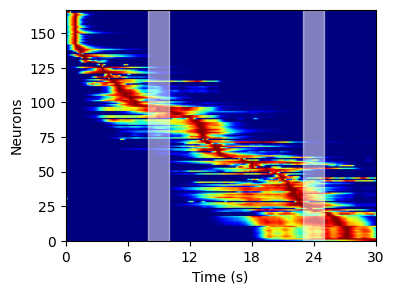

In [18]:
from func import plt_hs
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)

# Plot the sorted hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0, fig=fig, ax=ax)
ax.axvspan(8, 10, alpha=0.5, color='white', zorder=0)
ax.axvspan(23,25, alpha=0.5, color='white', zorder=0)
ax.set_xlabel('Time (s)')

print(norm_hs.shape)